# Retail Grocery Price Comparison Across China, the US, and Indonesia

## Problem Definition
Grocery prices can be difficult to compare across countries due to differences in currency and product sizes. This project explores this issue by using Python to standardise the data and compare grocery costs across China, the US, and Indonesia. The idea comes from my experience as an Indonesian student living in China and my curiosity about whether living here is actually cheaper. The target user is price-conscious consumers and individuals interested in comparing cost of living across countries. This includes students, travellers, and analysts who want to understand how the price of everyday goods differs between markets.


## Data Source
The dataset was manually collected. For Walmart (US) and Hypermart (Indonesia), I accessed the data through their official websites, while for Sam’s Club (China), I used their mobile application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading
This section imports the dataset and checks its structure. 

In [2]:
df = pd.read_csv("retail_prices.csv")
df.head()

,market,retailer,product_name,category,package_size,unit_type,price_local,currency,price_type
0,China,Sam's Club,Milk,Dairy,2.000,L,17.90,RMB,regular
1,US,Walmart,Milk,Dairy,1.890,L,1.84,USD,regular
2,Indonesia,Hypermart,Milk,Dairy,0.946,L,18590.00,IDR,regular
3,China,Sam's Club,Yogurt,Dairy,1230.000,g,53.90,RMB,regular
4,US,Walmart,Yogurt,Dairy,907.000,g,3.38,USD,regular


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   market        30 non-null     object 
 1   retailer      30 non-null     object 
 2   product_name  30 non-null     object 
 3   category      30 non-null     object 
 4   package_size  30 non-null     float64
 5   unit_type     30 non-null     object 
 6   price_local   30 non-null     float64
 7   currency      30 non-null     object 
 8   price_type    30 non-null     object 
dtypes: float64(2), object(7)
memory usage: 2.5+ KB


## 2. Data Cleaning 
This section removes empty rows and prepares the dataset for analysis.

In [4]:
df = df.dropna(how="all")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 33
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   market        30 non-null     object 
 1   retailer      30 non-null     object 
 2   product_name  30 non-null     object 
 3   category      30 non-null     object 
 4   package_size  30 non-null     float64
 5   unit_type     30 non-null     object 
 6   price_local   30 non-null     float64
 7   currency      30 non-null     object 
 8   price_type    30 non-null     object 
dtypes: float64(2), object(7)
memory usage: 2.3+ KB


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['market', 'retailer', 'product_name', 'category', 'package_size',
       'unit_type', 'price_local', 'currency', 'price_type'],
      dtype='object')

In [6]:
text_cols = ["market", "retailer", "product_name", "category", "unit_type", "currency", "price_type"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [7]:
df["package_size"] = pd.to_numeric(df["package_size"], errors="coerce")
df["price_local"] = pd.to_numeric(df["price_local"], errors="coerce")

df[["package_size", "price_local"]].head()

,package_size,price_local
0,2.000,17.90
1,1.890,1.84
2,0.946,18590.00
3,1230.000,53.90
4,907.000,3.38


## 3. Unit Standardisation
Since products come in different package sizes and units, I converted everything into litres and kilograms so they can be compared more fairly.

In [8]:
# convert ml to L
df.loc[df["unit_type"] == "ml", "package_size"] = df.loc[df["unit_type"] == "ml", "package_size"] / 1000
df.loc[df["unit_type"] == "ml", "unit_type"] = "L"

# convert g to kg
df.loc[df["unit_type"] == "g", "package_size"] = df.loc[df["unit_type"] == "g", "package_size"] / 1000
df.loc[df["unit_type"] == "g", "unit_type"] = "kg"

# show the table
df[["product_name", "package_size", "unit_type"]].head(15)

,product_name,package_size,unit_type
0,Milk,2.000,L
1,Milk,1.890,L
2,Milk,0.946,L
3,Yogurt,1.230,kg
4,Yogurt,0.907,kg
5,Yogurt,0.473,kg
7,Rice,5.000,kg
8,Rice,4.500,kg
9,Rice,5.000,kg
10,Bread,0.875,kg


### 4. Currency Conversion
Prices were collected in different currencies such as RMB, USD, and IDR. Hence, all prices are converted into USD as it is a standard currency for comparison.

In [9]:
exchange_rates = {
    "USD": 1.0,
    "RMB": 0.14,
    "IDR": 0.000065
}

df["price_usd"] = df["currency"].map(exchange_rates) * df["price_local"]

df[["market", "product_name", "price_local", "currency", "price_usd"]].head(10)

,market,product_name,price_local,currency,price_usd
0,China,Milk,17.90,RMB,2.506000
1,US,Milk,1.84,USD,1.840000
2,Indonesia,Milk,18590.00,IDR,1.208350
3,China,Yogurt,53.90,RMB,7.546000
4,US,Yogurt,3.38,USD,3.380000
5,Indonesia,Yogurt,54443.00,IDR,3.538795
7,China,Rice,59.90,RMB,8.386000
8,US,Rice,14.97,USD,14.970000
9,Indonesia,Rice,119900.00,IDR,7.793500
10,China,Bread,23.90,RMB,3.346000


## 5. Unit Price Calculation
This section calculate the unit price per kg/litre to allow products with different sizes to be compared fairly.

In [10]:
df["unit_price_usd"] = df["price_usd"] / df["package_size"]

df[["market", "product_name", "package_size", "unit_type", "price_usd", "unit_price_usd"]].head(15)

,market,product_name,package_size,unit_type,price_usd,unit_price_usd
0,China,Milk,2.000,L,2.506000,1.253000
1,US,Milk,1.890,L,1.840000,0.973545
2,Indonesia,Milk,0.946,L,1.208350,1.277326
3,China,Yogurt,1.230,kg,7.546000,6.134959
4,US,Yogurt,0.907,kg,3.380000,3.726571
5,Indonesia,Yogurt,0.473,kg,3.538795,7.481596
7,China,Rice,5.000,kg,8.386000,1.677200
8,US,Rice,4.500,kg,14.970000,3.326667
9,Indonesia,Rice,5.000,kg,7.793500,1.558700
10,China,Bread,0.875,kg,3.346000,3.824000


In [11]:
df.sort_values("unit_price_usd", ascending=False).head(10)

,market,retailer,product_name,category,package_size,unit_type,price_local,currency,price_type,price_usd,unit_price_usd
17,China,Sam's Club,Canned Tuna,Protein,0.960,kg,69.90,RMB,regular,9.786000,10.193750
19,Indonesia,Hypermart,Canned Tuna,Protein,0.170,kg,24990.00,IDR,regular,1.624350,9.555000
5,Indonesia,Hypermart,Yogurt,Dairy,0.473,kg,54443.00,IDR,discounted,3.538795,7.481596
18,US,Walmart,Canned Tuna,Protein,0.142,kg,0.96,USD,regular,0.960000,6.760563
3,China,Sam's Club,Yogurt,Dairy,1.230,kg,53.90,RMB,regular,7.546000,6.134959
11,US,Walmart,Bread,Grains,0.567,kg,2.74,USD,discounted,2.740000,4.832451
10,China,Sam's Club,Bread,Grains,0.875,kg,23.90,RMB,regular,3.346000,3.824000
4,US,Walmart,Yogurt,Dairy,0.907,kg,3.38,USD,regular,3.380000,3.726571
22,US,Walmart,Coca-cola,Beverages,1.330,L,4.82,USD,regular,4.820000,3.624060
8,US,Walmart,Rice,Grains,4.500,kg,14.97,USD,regular,14.970000,3.326667


## 6. Market-Level Analysis
This section compares the average unit price across the three markets.

In [12]:
avg_price = df.groupby("market")["unit_price_usd"].mean()
avg_price

market
China        2.651764
Indonesia    2.597756
US           2.807837
Name: unit_price_usd, dtype: float64

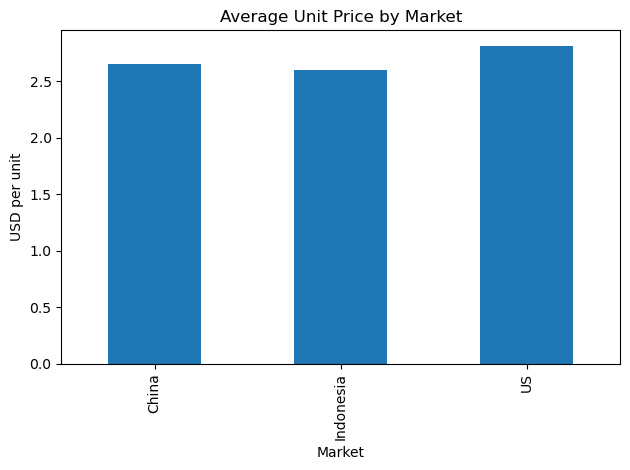

In [13]:
avg_price.plot(kind="bar")

plt.title("Average Unit Price by Market")
plt.ylabel("USD per unit")
plt.xlabel("Market")
plt.tight_layout()
plt.show()

This chart shows the average unit price across the three markets. Indonesia is the cheapest overall, while the US has the highest average price.

## 7. Product-Level Analysis
This section compares unit prices for each product across China, the US, and Indonesia.

In [14]:
df.groupby(["product_name", "market"])["unit_price_usd"].mean()

product_name       market   
Bottled water      China         0.443333
                   Indonesia     0.223853
                   US            1.511737
Bread              China         3.824000
                   Indonesia     2.635135
                   US            4.832451
Canned Tuna        China        10.193750
                   Indonesia     9.555000
                   US            6.760563
Coca-cola          China         1.128485
                   Indonesia     1.557400
                   US            3.624060
Eggs               China         0.088200
                   Indonesia     0.215150
                   US            0.139167
Laundry detergent  China         1.471842
                   Indonesia     1.356469
                   US            2.020270
Milk               China         1.253000
                   Indonesia     1.277326
                   US            0.973545
Rice               China         1.677200
                   Indonesia     1.558700
     

In [15]:
pivot = df.pivot_table(values="unit_price_usd", index="product_name", columns="market")
pivot = pivot[["China", "Indonesia", "US"]]
pivot

market,China,Indonesia,US
product_name,,,
Bottled water,0.443333,0.223853,1.511737
Bread,3.824000,2.635135,4.832451
Canned Tuna,10.193750,9.555000,6.760563
Coca-cola,1.128485,1.557400,3.624060
Eggs,0.088200,0.215150,0.139167
Laundry detergent,1.471842,1.356469,2.020270
Milk,1.253000,1.277326,0.973545
Rice,1.677200,1.558700,3.326667
Toilet paper,0.302867,0.116935,1.163333


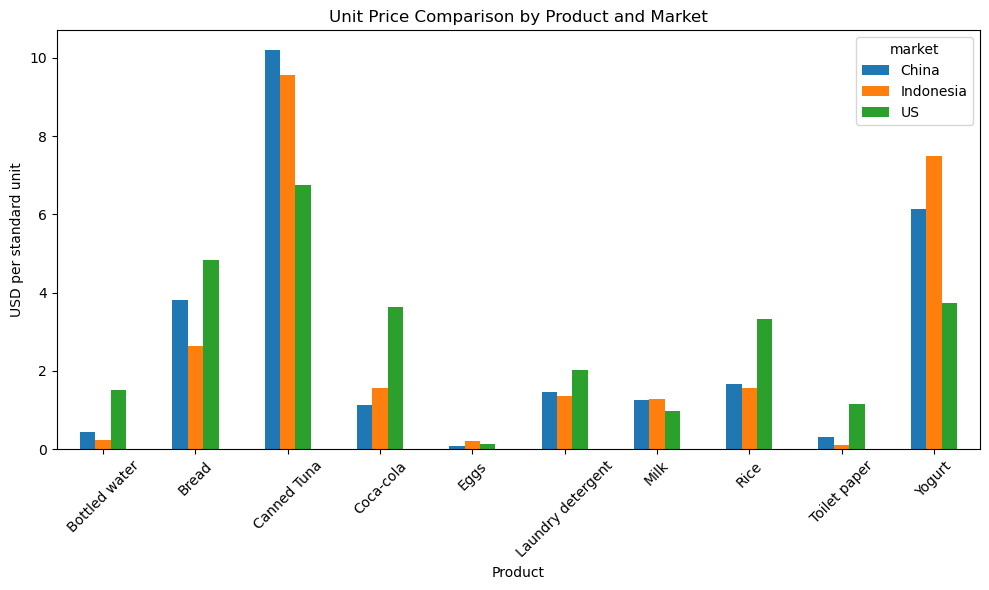

In [16]:
pivot.plot(kind="bar", figsize=(10,6))

plt.title("Unit Price Comparison by Product and Market")
plt.ylabel("USD per standard unit")
plt.xlabel("Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows that no single country is the cheapest for every product. Some items are cheaper in Indonesia, while others are cheaper in the US or China. This explains the importance of comparing products individually rather than fully relying on overall averages.

In [17]:
df.to_csv("retail_prices_cleaned.csv", index=False)

## 8. Final Output
This notebook shows the full process from raw data to cleaned data, followed by analysis and visual results. The results provide a clearer understanding of how grocery prices differ across countries and show that value depends on the type of product rather than the market as a whole.